<a href="https://colab.research.google.com/github/THEJoshinator20/ST-554-Project1-Template/blob/main/Project1_Task2_McClure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 4.0 MB/s eta 0:00:00


In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from IPython.display import display
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

This task involves conducting an extensive EDA to understand the relationships the sensor and weather
variables have with the C6H6(GT) (benzene) pollutant measurement.

##Step 1: Import and and Remove Missing Values

###Importing Dataset

In [3]:
pip install ucimlrepo

In [4]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
air_quality = fetch_ucirepo(id=360)

# data (as pandas dataframes)
X = air_quality.data.features
y = air_quality.data.targets

# metadata
#print(air_quality.metadata)

# variable information
print(air_quality.variables)


             name     role         type demographic  \
0            Date  Feature         Date        None   
1            Time  Feature  Categorical        None   
2          CO(GT)  Feature      Integer        None   
3     PT08.S1(CO)  Feature  Categorical        None   
4        NMHC(GT)  Feature      Integer        None   
5        C6H6(GT)  Feature   Continuous        None   
6   PT08.S2(NMHC)  Feature  Categorical        None   
7         NOx(GT)  Feature      Integer        None   
8    PT08.S3(NOx)  Feature  Categorical        None   
9         NO2(GT)  Feature      Integer        None   
10   PT08.S4(NO2)  Feature  Categorical        None   
11    PT08.S5(O3)  Feature  Categorical        None   
12              T  Feature   Continuous        None   
13             RH  Feature   Continuous        None   
14             AH  Feature   Continuous        None   

                                          description       units  \
0                                                N

###Remove Missing Values / Isolate Variables of Interest

In [5]:
air_quality_df = pd.DataFrame(X)
air_quality_df.head()
#print(air_quality_df.shape)

#Produce copy to ensure data always has consistant source
aqual = air_quality_df.copy()

#Get rid of missing variables labeled as -200 for all variables
#(I am sure there is a neater way but this makes me feel more sure that its done right)
aqual = aqual[~(aqual['CO(GT)'].isin([-200]))]
aqual = aqual[~(aqual['PT08.S1(CO)'].isin([-200]))]
aqual = aqual[~(aqual['NMHC(GT)'].isin([-200]))]
aqual = aqual[~(aqual['C6H6(GT)'].isin([-200]))]
aqual = aqual[~(aqual['PT08.S2(NMHC)'].isin([-200]))]
aqual = aqual[~(aqual['NOx(GT)'].isin([-200]))]
aqual = aqual[~(aqual['PT08.S3(NOx)'].isin([-200]))]
aqual = aqual[~(aqual['NO2(GT)'].isin([-200]))]
aqual = aqual[~(aqual['PT08.S4(NO2)'].isin([-200]))]
aqual = aqual[~(aqual['PT08.S5(O3)'].isin([-200]))]
aqual = aqual[~(aqual['T'].isin([-200]))]
aqual = aqual[~(aqual['RH'].isin([-200]))]
aqual = aqual[~(aqual['AH'].isin([-200]))]

#Reduce model down to variables interested in for Task 2 EDA (Weather, Sensor Data(no "true" variables), Variable C6H6(GT), and Date/Time)
aqual = aqual[['Date', 'Time', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']]
display(aqual)

# Double checking for any missing characters and duplicate rows
print(f"In sorted dataset is there missing values: {aqual.isnull().values.any()}")
print(f"In sorted dataset is there duplicate values: {aqual.duplicated().values.any()}")


,Date,Time,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,1360,11.9,1046,1056,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,1292,9.4,955,1174,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,1402,9.0,939,1140,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,1376,9.2,948,1092,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1272,6.5,836,1205,1490,1110,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...
1226,4/30/2004,20:00:00,1449,19.5,1282,625,2100,1569,19.1,61.1,1.3345
1227,4/30/2004,21:00:00,1363,15.1,1152,684,1951,1495,18.2,65.4,1.3529
1228,4/30/2004,22:00:00,1371,14.6,1136,689,1927,1471,18.1,66.1,1.3579
1229,4/30/2004,23:00:00,1406,13.7,1107,718,1872,1384,17.7,66.9,1.3422


In sorted dataset is there missing values: False
In sorted dataset is there duplicate values: False


Initial EDA for Air Quality Data

In [40]:
# Convert 'Date' column to datetime objects
aqual['Date'] = pd.to_datetime(aqual['Date'], format='%m/%d/%Y')

# Create a new 'Month_Year' column
aqual['Month_Year'] = aqual['Date'].dt.to_period('M').astype(str)

def temp(temp_val):
  if temp_val <= 10:
    return "10 Degrees or less"
  elif temp_val <= 20:
    return "10 to 20 Degrees"
  elif temp_val <= 30:
    return "30 Degrees or less"
  else:
    return "30 Degrees or more"

aqual["Heat"] = aqual["T"].apply(temp)

display(aqual.describe())

,Date,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,827,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000
mean,2004-04-04 02:50:38.452237056,1207.879081,10.771100,966.116082,963.297461,1600.620314,1045.812576,15.601451,49.050181,0.831853
min,2004-03-10 00:00:00,753.000000,0.500000,448.000000,461.000000,955.000000,263.000000,6.300000,14.900000,0.402300
25%,2004-03-24 00:00:00,1017.000000,4.800000,754.000000,769.000000,1369.500000,760.000000,11.900000,36.700000,0.718950
50%,2004-04-02 00:00:00,1172.000000,9.100000,944.000000,920.000000,1556.000000,1009.000000,15.000000,49.600000,0.817700
75%,2004-04-15 00:00:00,1380.000000,14.800000,1142.500000,1131.000000,1783.500000,1320.000000,18.300000,60.550000,0.927500
max,2004-05-01 00:00:00,2040.000000,39.200000,1754.000000,1935.000000,2679.000000,2359.000000,30.000000,83.200000,1.485200
std,NaN,241.816997,7.418134,266.424557,265.914168,302.291793,400.134662,4.825304,15.266746,0.178506


###TLF's of C6H6 with PT08 and Tempurature with and without Date

<Figure size 800x400 with 0 Axes>

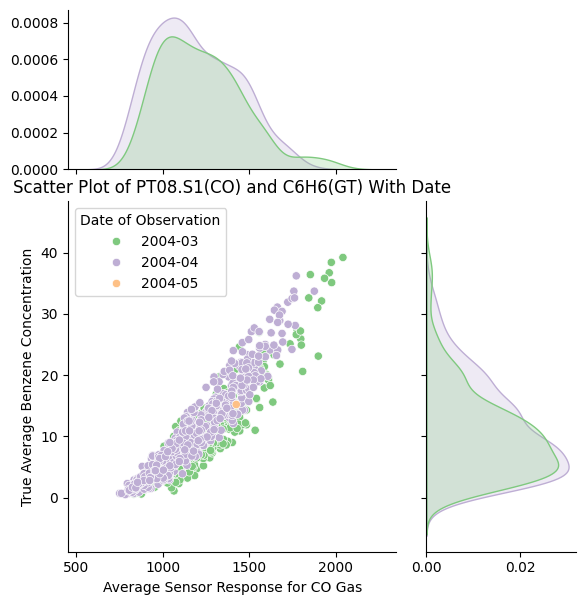

<Figure size 800x600 with 0 Axes>

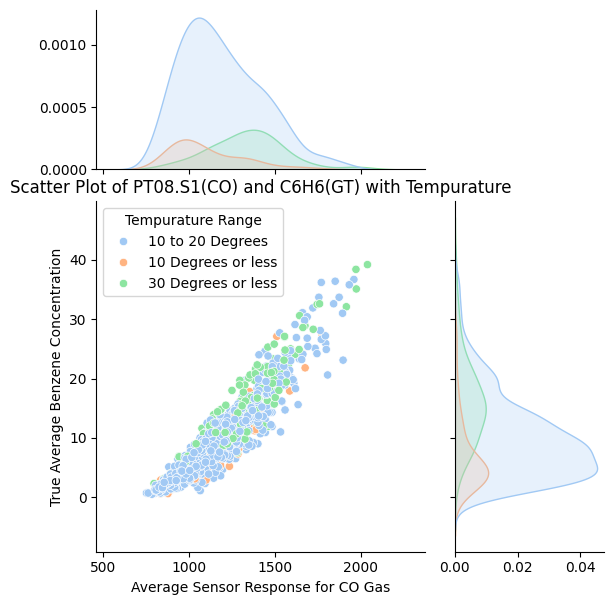

In [91]:
plt.figure(figsize=(8, 4))
cpdate = sns.jointplot(data = aqual, x = "PT08.S1(CO)", y = "C6H6(GT)", hue = "Month_Year", palette= "Accent"
                      , height = 6, ratio = 2, marginal_ticks = True)
plt.subplots_adjust(top=1)
plt.xlabel("Average Sensor Response for CO Gas")
plt.ylabel("True Average Benzene Concentration")
plt.title("Scatter Plot of PT08.S1(CO) and C6H6(GT) With Date")
plt.legend(title='Date of Observation')
plt.show()

plt.figure(figsize=(8, 6))
cptemp = sns.jointplot(data = aqual, x = "PT08.S1(CO)", y = "C6H6(GT)", hue = "Heat", palette= "pastel"
                      , height = 6, ratio = 2, marginal_ticks = True)
plt.subplots_adjust(top=1)
plt.xlabel("Average Sensor Response for CO Gas")
plt.ylabel("True Average Benzene Concentration")
plt.title("Scatter Plot of PT08.S1(CO) and C6H6(GT) with Tempurature")
plt.legend(title='Tempurature Range')
plt.show()

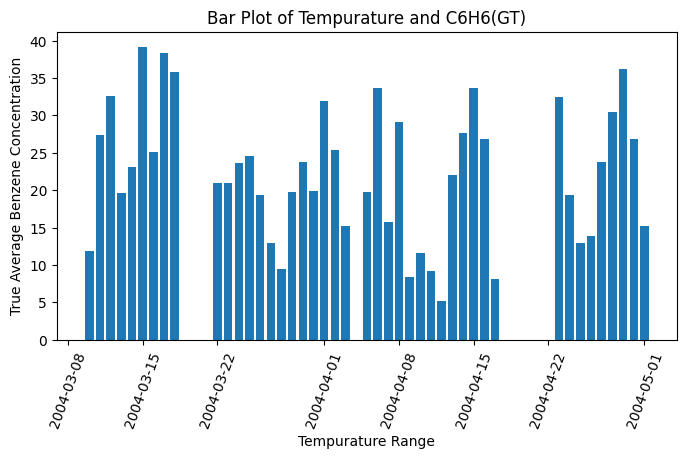

In [63]:
plt.figure(figsize=(8, 4))
plt.bar(aqual["Date"], aqual["C6H6(GT)"])
plt.xlabel("Tempurature Range")
plt.ylabel("True Average Benzene Concentration")
plt.title("Bar Plot of Tempurature and C6H6(GT)")
plt.tick_params(axis='x', rotation=70)
plt.show()

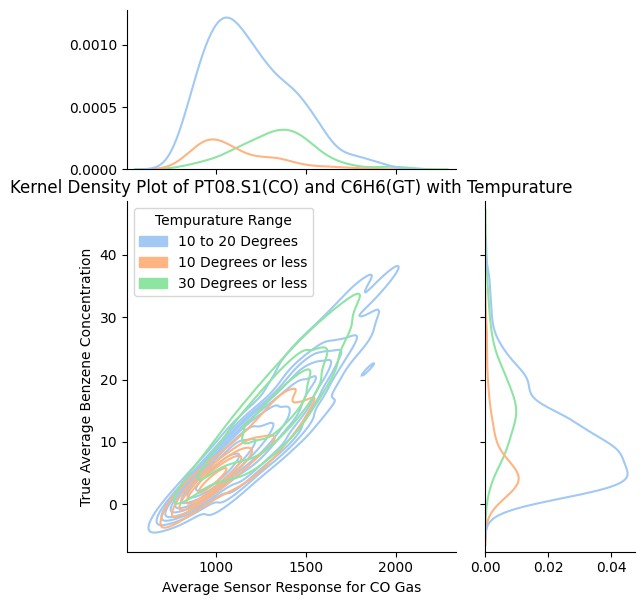

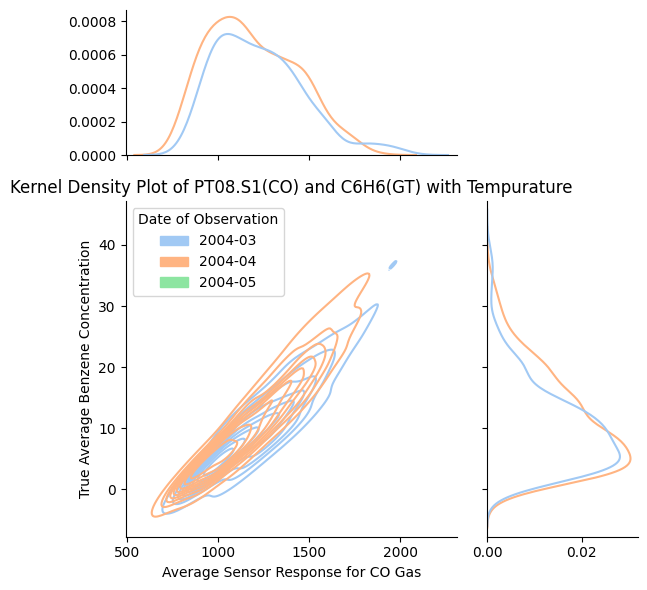

In [112]:
kercpt = sns.jointplot(data = aqual, x = "PT08.S1(CO)", y = "C6H6(GT)", kind = "kde", hue = "Heat", palette= "pastel"
                      , height = 6, ratio = 2, marginal_ticks = True)
plt.subplots_adjust(top=1)
plt.ylabel("True Average Benzene Concentration")
plt.xlabel("Average Sensor Response for CO Gas")
plt.title("Kernel Density Plot of PT08.S1(CO) and C6H6(GT) with Tempurature")
# Get unique values for the 'Heat' column to create legend entries
unique_heat_values = aqual['Heat'].unique()

# Get the color palette used by seaborn.jointplot
# The number of colors should match the number of unique hue values
n_colors = len(unique_heat_values)
current_palette = sns.color_palette("pastel", n_colors=n_colors)

# Create a mapping from heat value to color
heat_color_map = dict(zip(unique_heat_values, current_palette))

# Create custom legend handles using mpatches.Patch
legend_handles = [mpatches.Patch(color=heat_color_map[val], label=val) for val in unique_heat_values]

# Add the legend to the jointplot's main axes
kercpt.ax_joint.legend(handles=legend_handles, title='Tempurature Range', loc='upper left')
plt.show()

print("\n\n")

kercpd = sns.jointplot(data = aqual, x = "PT08.S1(CO)", y = "C6H6(GT)", kind = "kde", hue = "Month_Year", palette= "pastel"
                      , height = 6, ratio = 2, marginal_ticks = True)
plt.subplots_adjust(top=1)
plt.ylabel("True Average Benzene Concentration")
plt.xlabel("Average Sensor Response for CO Gas")
plt.title("Kernel Density Plot of PT08.S1(CO) and C6H6(GT) with Tempurature")
# Get unique values for the 'Heat' column to create legend entries
unique_date_values = aqual['Month_Year'].unique()

# Get the color palette used by seaborn.jointplot
# The number of colors should match the number of unique hue values
n_colors = len(unique_date_values)
current_palette = sns.color_palette("pastel", n_colors=n_colors)

# Create a mapping from date value to color
date_color_map = dict(zip(unique_date_values, current_palette))

# Create custom legend handles using mpatches.Patch
legend_handles = [mpatches.Patch(color=date_color_map[val], label=val) for val in unique_date_values]

# Add the legend to the jointplot's main axes
kercpd.ax_joint.legend(handles=legend_handles, title='Date of Observation', loc='upper left')
plt.tight_layout()
plt.show()